## ✨ Random Image Edge Improvement Using Segmentation Mask

This section randomly selects an image along with its corresponding segmentation mask, applies basic morphological operations to enhance the object's edges, and visualizes the results.

### 🧠 What It Does:
- Loads a random image and its mask.
- Applies **edge refinement** using morphological operations (e.g., dilation, erosion, or blurring).
- Displays both the **original** and **edge-improved** versions side by side.

> This technique is useful for improving the clarity of object boundaries before further processing or model training.


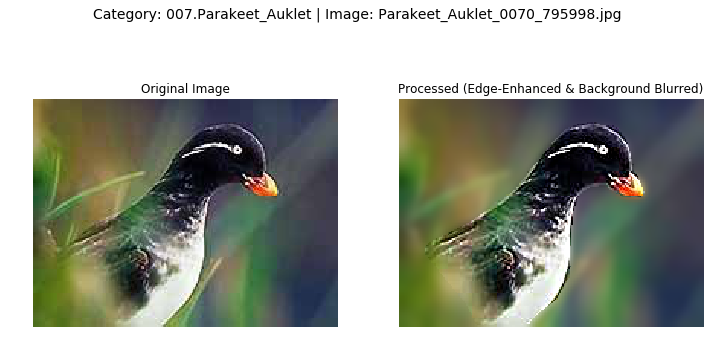

In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

images_folder = r"C:\arpit\project3\CUB_200_2011\images"
segmentations_folder = r"C:\arpit\project3\CUB_200_2011\segmentations"

# Get list of category folders (each representing a bird species)
categories = [d for d in os.listdir(images_folder) if os.path.isdir(os.path.join(images_folder, d))]

# Choose a random category and a random image within that category
random_category = random.choice(categories)
category_path = os.path.join(images_folder, random_category)
image_files = [f for f in os.listdir(category_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
random_image_file = random.choice(image_files)
image_path = os.path.join(category_path, random_image_file)

# Construct corresponding segmentation mask path
seg_category_path = os.path.join(segmentations_folder, random_category)
base_name, _ = os.path.splitext(random_image_file)
seg_file = base_name + ".png"
seg_path = os.path.join(seg_category_path, seg_file)

# READ IMAGE
image = cv2.imread(image_path)
mask = cv2.imread(seg_path, cv2.IMREAD_GRAYSCALE)  # read mask in grayscale

if image is None or mask is None:
    print("Error: Could not load image or mask.")
else:
    # Resize mask to image size if needed
    if mask.shape != image.shape[:2]:
        mask = cv2.resize(mask, (image.shape[1], image.shape[0]))
    
    # Threshold the mask to obtain a binary mask (assuming mask values >128 are foreground)
    _, binary_mask = cv2.threshold(mask, 128, 255, cv2.THRESH_BINARY)
    
    # Convert binary mask to 3 channels for later compositing
    binary_mask_3c = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2BGR)
    # Create inverse mask for background
    inv_mask = cv2.bitwise_not(binary_mask)
    inv_mask_3c = cv2.cvtColor(inv_mask, cv2.COLOR_GRAY2BGR)
    
    # --- Create a sharpened version of the object ---
    blurred_for_sharpen = cv2.GaussianBlur(image, (0, 0), sigmaX=3)
    sharpened = cv2.addWeighted(image, 1.5, blurred_for_sharpen, -0.5, 0)
    
    # --- Create a blurred background ---
    blurred_background = cv2.GaussianBlur(image, (15, 15), sigmaX=0)
    
    # --- Composite the final image ---
    composite = np.where(binary_mask_3c==255, sharpened, blurred_background)
    
    # Alternatively, using bitwise operations:
    obj_part = cv2.bitwise_and(sharpened, binary_mask_3c)
    bg_part = cv2.bitwise_and(blurred_background, inv_mask_3c)
    composite = cv2.add(obj_part, bg_part)
    
    # Convert BGR to RGB for displaying with matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    composite_rgb = cv2.cvtColor(composite, cv2.COLOR_BGR2RGB)
    
    # Display the original and processed images side by side
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(composite_rgb)
    plt.title("Processed (Edge-Enhanced & Background Blurred)")
    plt.axis("off")
    
    plt.suptitle(f"Category: {random_category} | Image: {random_image_file}", fontsize=14)
    plt.show()


# ---------------------------------------------------------------
# 📁 Creating a New Dataset for Aircraft Classification
# ---------------------------------------------------------------
This script generates a structured image dataset for classification using
the CUB_200_2011 bird dataset. The dataset is enhanced through the following:

✅ 1. Cropping: Each image is cropped using ground truth bounding boxes.
✅ 2. Augmentation: Each class gets 10 augmented images (rotate, flip, brightness).
✅ 3. (Future Option) Edge detection + background blur for visual emphasis.

🔧 Dependencies: OpenCV, PIL (Pillow), os, random
 ---------------------------------------------------------------

Edge-enhanced and background blurred images have been saved.


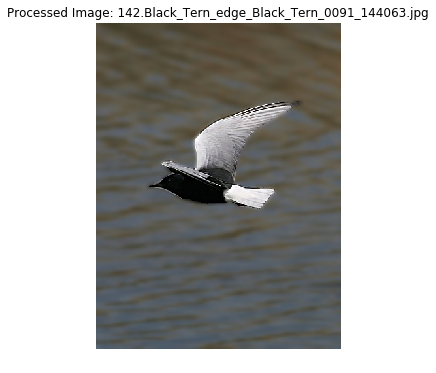

In [ ]:
import os
import cv2
import numpy as np
import random
import shutil
import matplotlib.pyplot as plt

images_folder = r"C:\arpit\project3\CUB_200_2011\images"
segmentations_folder = r"C:\arpit\project3\CUB_200_2011\segmentations"
output_folder = r"C:\arpit\project3\new_dataset\edge_sharp_bg_blur"

# Create the output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Utility: For each category folder, process all images.
def process_image(image_path, seg_path):
    """
    Reads an image and its segmentation mask, and produces a composite image where
    the object is sharpened (edge-enhanced) and the background is blurred.
    """
    # Read image and segmentation mask.
    image = cv2.imread(image_path)
    mask = cv2.imread(seg_path, cv2.IMREAD_GRAYSCALE)
    
    if image is None or mask is None:
        return None

    h, w = image.shape[:2]
    # Resize mask if needed.
    if mask.shape != (h, w):
        mask = cv2.resize(mask, (w, h))
        
    # Threshold mask to get binary mask.
    _, binary_mask = cv2.threshold(mask, 128, 255, cv2.THRESH_BINARY)
    
    # Convert binary mask to 3 channels.
    binary_mask_3c = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2BGR)
    inv_mask = cv2.bitwise_not(binary_mask)
    inv_mask_3c = cv2.cvtColor(inv_mask, cv2.COLOR_GRAY2BGR)
    
    # Sharpen the object using unsharp masking.
    blurred_for_sharpen = cv2.GaussianBlur(image, (0, 0), sigmaX=3)
    sharpened = cv2.addWeighted(image, 1.5, blurred_for_sharpen, -0.5, 0)
    
    # Blur the background.
    blurred_background = cv2.GaussianBlur(image, (15, 15), sigmaX=0)
    
    # Composite: use the mask to select between the sharpened object and blurred background.
    obj_part = cv2.bitwise_and(sharpened, binary_mask_3c)
    bg_part = cv2.bitwise_and(blurred_background, inv_mask_3c)
    composite = cv2.add(obj_part, bg_part)
    
    return composite

# Process images from each category.
# We assume that the segmentation folder has the same category structure
# and that segmentation files have the same base filename with a .png extension.
for category in os.listdir(images_folder):
    cat_img_path = os.path.join(images_folder, category)
    cat_seg_path = os.path.join(segmentations_folder, category)
    if not os.path.isdir(cat_img_path):
        continue
    # Create an output subfolder for this category.
    output_cat = os.path.join(output_folder, category)
    os.makedirs(output_cat, exist_ok=True)
    
    for fname in os.listdir(cat_img_path):
        if fname.lower().endswith(('.png','.jpg','.jpeg')):
            image_path = os.path.join(cat_img_path, fname)
            base_name, _ = os.path.splitext(fname)
            seg_file = base_name + ".png"  # assuming segmentation masks are .png
            seg_path = os.path.join(cat_seg_path, seg_file)
            if not os.path.exists(seg_path):
                # Skip if corresponding segmentation mask is not found.
                continue
            composite = process_image(image_path, seg_path)
            if composite is not None:
                out_fname = f"{category}_edge_{fname}"
                cv2.imwrite(os.path.join(output_cat, out_fname), composite)

print("Edge-enhanced and background blurred images have been saved.")

# Optionally, display a random processed image:
all_processed = []
for root, dirs, files in os.walk(output_folder):
    for f in files:
        if f.lower().endswith(('.png','.jpg','.jpeg')):
            all_processed.append(os.path.join(root, f))
            
if all_processed:
    random_img_path = random.choice(all_processed)
    processed_img = cv2.imread(random_img_path)
    processed_img_rgb = cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(6,6))
    plt.imshow(processed_img_rgb)
    plt.title(f"Processed Image: {os.path.basename(random_img_path)}")
    plt.axis("off")
    plt.show()


In [ ]:
import os
import random
import cv2
from PIL import Image, ImageEnhance, ImageOps

# Paths
images_folder = r"C:\arpit\project3\CUB_200_2011\images"
bounding_boxes_file = r"C:\arpit\project3\CUB_200_2011\bounding_boxes.txt"
images_txt_file      = r"C:\arpit\project3\CUB_200_2011\images.txt"
new_dataset_folder   = r"C:\arpit\project3\new_dataset"
cropped_folder       = os.path.join(new_dataset_folder, "cropped")
aug_folder           = os.path.join(new_dataset_folder, "augmentation")

# Ensure output folders exist
os.makedirs(cropped_folder, exist_ok=True)
os.makedirs(aug_folder, exist_ok=True)

# 1. Load image ID → relative path
id_to_path = {}
with open(images_txt_file, 'r') as f:
    for line in f:
        img_id, rel_path = line.strip().split()
        id_to_path[img_id] = rel_path

# 2. Load bounding boxes (keyed by image ID)
bb_dict = {}
with open(bounding_boxes_file, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 5:
            img_id = parts[0]
            x, y, w, h = map(float, parts[1:])
            bb_dict[img_id] = (int(x), int(y), int(w), int(h))

# 3. Crop all images using their bounding boxes, and build class_to_images map
class_to_images = {}
for img_id, rel_path in id_to_path.items():
    if img_id not in bb_dict:
        continue  # skip if no bbox

    # Determine category from the first folder in the relative path
    parts = rel_path.replace("\\", "/").split("/")
    category = parts[0]
    abs_path = os.path.join(images_folder, *parts)

    # Read and crop
    img = cv2.imread(abs_path)
    if img is None:
        continue
    x, y, w, h = bb_dict[img_id]
    cropped = img[y : y + h, x : x + w]

    # Save cropped image
    fname = os.path.basename(rel_path)
    out_name = f"{category}_crop_{fname}"
    cv2.imwrite(os.path.join(cropped_folder, out_name), cropped)

    # Add to class list for augmentation
    class_to_images.setdefault(category, []).append(abs_path)

# 4. Augment 10 images per class (one random transform per image)
for category, image_list in class_to_images.items():
    class_aug_dir = os.path.join(aug_folder, category)
    os.makedirs(class_aug_dir, exist_ok=True)

    selected = random.sample(image_list, min(len(image_list), 10))
    for idx, img_path in enumerate(selected):
        try:
            img_pil = Image.open(img_path)
        except:
            continue

        # Choose one augmentation at random
        aug_fn = random.choice([
            lambda im: ImageOps.mirror(im),
            lambda im: im.rotate(15, expand=True),
            lambda im: im.rotate(-15, expand=True),
            lambda im: ImageEnhance.Brightness(im).enhance(1.2),
        ])
        aug_img = aug_fn(img_pil)

        # Save augmented image
        aug_name = f"{category}_aug_{idx}.jpg"
        aug_img.save(os.path.join(class_aug_dir, aug_name))

print("Cropped and augmented dataset creation complete.")


Cropped and augmented dataset creation complete.


## 📁 Final Dataset Preparation for Classification (ResNet Format)

In this step, we consolidate three processed data sources into a single dataset structured for image classification tasks:

### ✅ Techniques Applied:
1. **Cropping** — Images cropped using ground truth bounding boxes (`cropped/` folder).
2. **Augmentation** — Class-wise image augmentations like flipping, rotation, and brightness adjustment (`augmentation/` folder).
3. **Edge Detection & Background Blur** — Enhanced images with edge sharpness and background blur applied (`edge_sharp_bg_blur/` folder, 20 images/class).

### 📦 Output Folder Structure:
The dataset is split into training and testing sets in a structure compatible with PyTorch's `ImageFolder` or Keras’ `ImageDataGenerator`.

```text
resnet_dataset/
├── train/
│   ├── class_1/
│   ├── class_2/
│   └── ...
└── test/
    ├── class_1/
    ├── class_2/
    └── ...



### 📊 Split Strategy:
- **80%** of the images go into the `train/` folder.
- **20%** are held out in the `test/` folder.
- All images are automatically grouped by class.

This format is ready to be used with PyTorch’s `ImageFolder` or Keras’ `ImageDataGenerator` for model training.

➡️ Run the following cell to generate the final dataset:


In [18]:
import os
import shutil
import random

# Input folders
cropped_folder = r"C:\arpit\project3\new_dataset\cropped"
augmented_folder = r"C:\arpit\project3\new_dataset\augmentation"
edge_folder = r"C:\arpit\project3\new_dataset\edge_sharp_bg_blur"

# Output folders
output_base = r"C:\arpit\project3\resnet_dataset"
train_folder = os.path.join(output_base, "train")
test_folder = os.path.join(output_base, "test")

# Create train/test base folders
for base in [train_folder, test_folder]:
    os.makedirs(base, exist_ok=True)

def copy_images(image_paths, dest_dir):
    for path in image_paths:
        cls = os.path.basename(os.path.dirname(path))
        class_dir = os.path.join(dest_dir, cls)
        os.makedirs(class_dir, exist_ok=True)
        shutil.copy(path, os.path.join(class_dir, os.path.basename(path)))

# Collect all images per class from cropped + augmented + edge
class_images = {}

# Cropped
for cls in os.listdir(cropped_folder):
    cls_path = os.path.join(cropped_folder, cls)
    if os.path.isdir(cls_path):
        for f in os.listdir(cls_path):
            class_images.setdefault(cls, []).append(os.path.join(cls_path, f))

# Augmented
for cls in os.listdir(augmented_folder):
    cls_path = os.path.join(augmented_folder, cls)
    if os.path.isdir(cls_path):
        for f in os.listdir(cls_path):
            class_images.setdefault(cls, []).append(os.path.join(cls_path, f))

# Edge (only 20 per class)
for cls in os.listdir(edge_folder):
    cls_path = os.path.join(edge_folder, cls)
    if os.path.isdir(cls_path):
        files = os.listdir(cls_path)
        selected = random.sample(files, min(20, len(files)))
        for f in selected:
            class_images.setdefault(cls, []).append(os.path.join(cls_path, f))

# Now split into train (80%) and test (20%) and copy
for cls, img_list in class_images.items():
    random.shuffle(img_list)
    split_idx = int(len(img_list) * 0.8)
    train_imgs = img_list[:split_idx]
    test_imgs = img_list[split_idx:]

    copy_images(train_imgs, train_folder)
    copy_images(test_imgs, test_folder)

print("Dataset prepared in ResNet format.")


Dataset prepared in ResNet format.
